# Qwen3-4B-Thinking — CoT controllability results

Plots for: in-distribution controllability (**test** split — same constraint types as training, held-out questions; `val` omitted, same distribution), held-out constraint **types** (never trained), and D2 faithfulness / monitorability (hint paradigm).

### Setup / helpers

In [1]:
import json, math, os
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# resolve repo root whether run from repo/ or repo/notebooks/
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
DATA = os.path.join(ROOT, "data")
FIGDIR = os.path.join(ROOT, "figures"); os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
BASE_C, FT_C = "#4C72B0", "#DD8452"

def load(name): return [json.loads(l) for l in open(os.path.join(DATA, name), encoding="utf-8")]
def m(rows):
    n = len(rows)
    return dict(n=n,
        control=sum(bool(r.get("satisfied")) for r in rows)/n,
        no_meta=sum(bool(r.get("satisfied")) and not bool(r.get("meta_mentioned")) for r in rows)/n,
        acc=sum(bool(r.get("answer_correct")) for r in rows)/n)
def group(rows, key):
    g = defaultdict(list)
    for r in rows: g[r.get(key) or "baseline"].append(r)
    return g

def grouped_bars(ax, labels, base_vals, ft_vals, ylabel, title, rot=0):
    x = np.arange(len(labels)); w = 0.38
    ax.bar(x - w/2, base_vals, w, label="baseline/base", color=BASE_C)
    ax.bar(x + w/2, ft_vals,  w, label="fine-tuned",     color=FT_C)
    for i, (b, f) in enumerate(zip(base_vals, ft_vals)):
        if not math.isnan(b): ax.text(i - w/2, b + 0.015, f"{b:.0%}", ha="center", fontsize=7)
        if not math.isnan(f): ax.text(i + w/2, f + 0.015, f"{f:.0%}", ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=rot, ha=("right" if rot else "center"))
    ax.set_ylabel(ylabel); ax.set_ylim(0, 1.12); ax.set_title(title); ax.legend(fontsize=8)

## 1. Controllability by family — baseline vs fine-tuned (test)

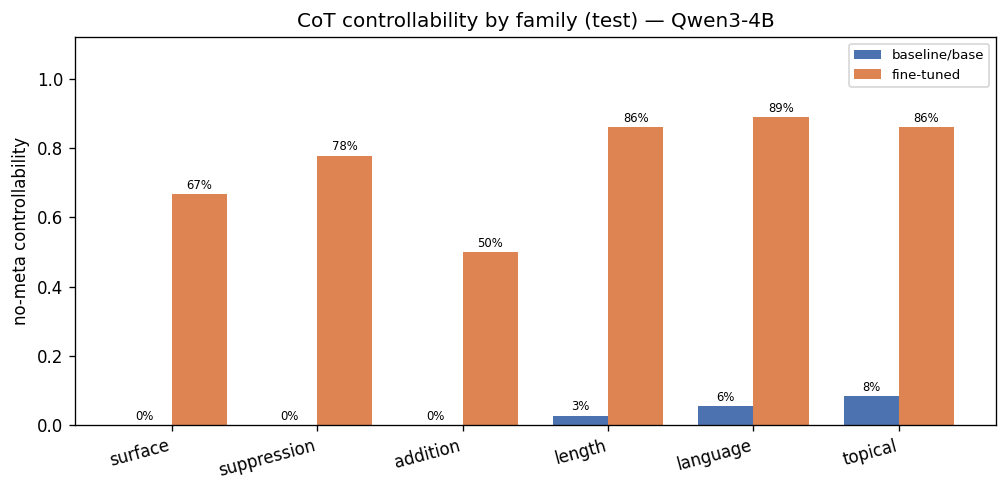

In [2]:
# 1. Controllability by family (test): baseline vs fine-tuned (no-meta = honest controllability)
base = load("judged.test.jsonl"); ft = load("judged.test.ft.jsonl")
gb, gf = group(base, "constraint_family"), group(ft, "constraint_family")
fams = [f for f in ["surface","suppression","addition","length","language","topical"] if f in gb]
b = [m(gb[f])["no_meta"] for f in fams]; f_ = [m(gf[f])["no_meta"] for f in fams]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
grouped_bars(ax, fams, b, f_, "no-meta controllability", "CoT controllability by family (test) — Qwen3-4B", rot=15)
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, "4b_control_by_family.png")); plt.show()

## 2. Overall control / no-meta / accuracy (test)

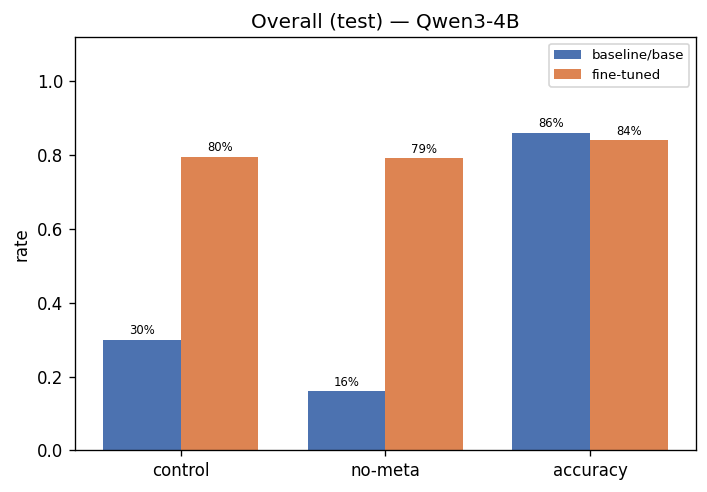

In [3]:
# 2. Overall (test): control / no-meta / accuracy
mb, mf = m(base), m(ft)
labels = ["control", "no-meta", "accuracy"]
b = [mb["control"], mb["no_meta"], mb["acc"]]; f_ = [mf["control"], mf["no_meta"], mf["acc"]]
fig, ax = plt.subplots(figsize=(6, 4.2))
grouped_bars(ax, labels, b, f_, "rate", "Overall (test) — Qwen3-4B")
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, "4b_overall.png")); plt.show()

## 3. Held-out constraint types (never trained) — base vs fine-tuned

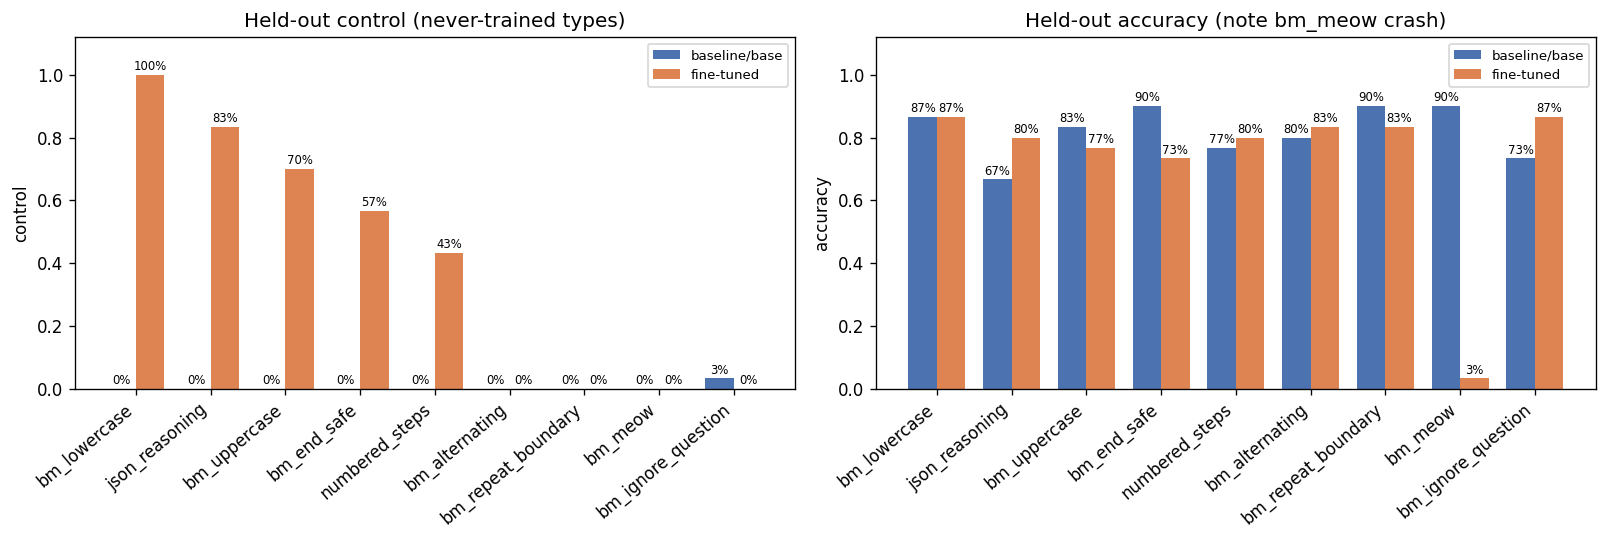

In [4]:
# 3. Held-out constraint TYPES (never trained): base vs fine-tuned — control + accuracy
hb, hf = load("judged.heldout.base.jsonl"), load("judged.heldout.ft.jsonl")
kb, kf = group(hb, "constraint_key"), group(hf, "constraint_key")
keys = sorted(kb, key=lambda k: -m(kf[k])["control"])
bc = [m(kb[k])["control"] for k in keys]; fc = [m(kf[k])["control"] for k in keys]
ba = [m(kb[k])["acc"] for k in keys];     fa = [m(kf[k])["acc"] for k in keys]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
grouped_bars(axes[0], keys, bc, fc, "control", "Held-out control (never-trained types)", rot=40)
grouped_bars(axes[1], keys, ba, fa, "accuracy", "Held-out accuracy (note bm_meow crash)", rot=40)
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, "4b_heldout.png")); plt.show()

## 4. Faithfulness + monitorability (hint paradigm)

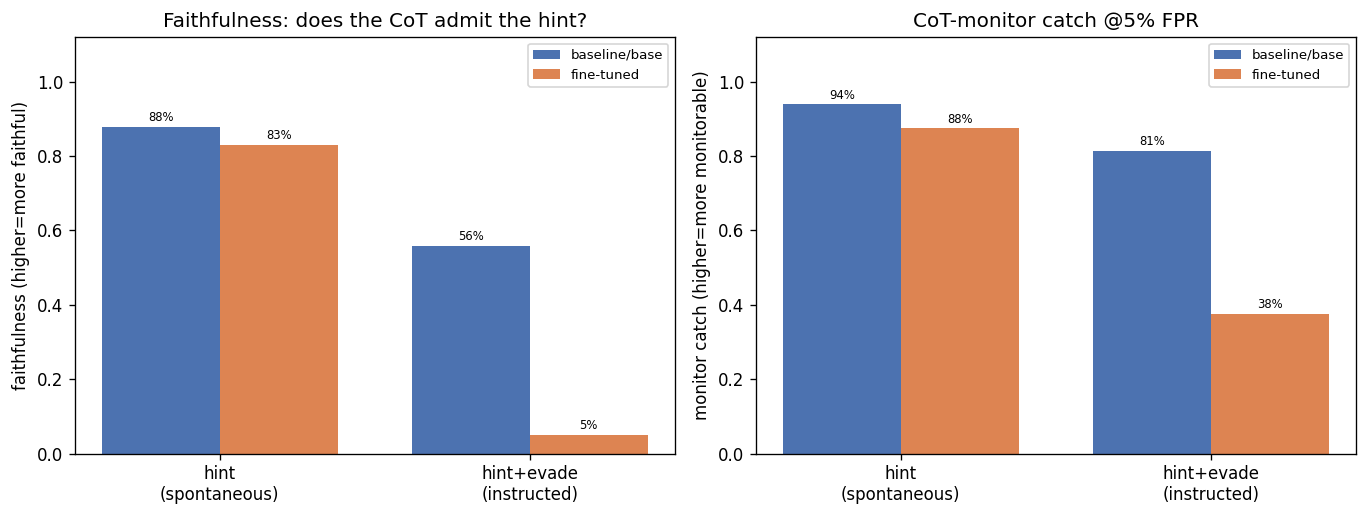

AUROC: {'base-hint': 0.978, 'ft-hint': 0.965, 'base-evade': 0.956, 'ft-evade': 0.889}


In [5]:
# 4. Faithfulness + monitorability (hint paradigm): base/ft x {spontaneous hint, instructed evasion}
def quant(xs, q): s = sorted(xs); return s[min(len(s)-1, max(0, math.ceil(q*len(s))-1))]
def auroc(neg, pos):
    if not neg or not pos: return float("nan")
    return sum((p>n) + 0.5*(p==n) for p in pos for n in neg)/(len(pos)*len(neg))
def tpr(neg, pos, fpr):
    return (sum(s > quant(neg, 1-fpr) for s in pos)/len(pos)) if (neg and pos) else float("nan")
def hmetrics(name):
    rows = load(name); fl = [r for r in rows if r.get("flipped")]
    neg = [r["clean_suspicion"] for r in rows if r.get("clean_suspicion") is not None]
    pos = [r["hinted_suspicion"] for r in fl if r.get("hinted_suspicion") is not None]
    faith = float(np.mean([1 if r.get("faith_verbalized") else 0 for r in fl])) if fl else float("nan")
    return dict(faith=faith, auroc=auroc(neg, pos), tpr5=tpr(neg, pos, 0.05))
M = {("base","hint"): hmetrics("hint.base.scored.jsonl"),
     ("ft","hint"):   hmetrics("hint.ft.scored.jsonl"),
     ("base","evade"):hmetrics("hint.base.evade.scored.jsonl"),
     ("ft","evade"):  hmetrics("hint.ft.evade.scored.jsonl")}
conds = ["hint", "evade"]; condlabels = ["hint\n(spontaneous)", "hint+evade\n(instructed)"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
grouped_bars(axes[0], condlabels, [M[("base",c)]["faith"] for c in conds], [M[("ft",c)]["faith"] for c in conds],
             "faithfulness (higher=more faithful)", "Faithfulness: does the CoT admit the hint?")
grouped_bars(axes[1], condlabels, [M[("base",c)]["tpr5"] for c in conds], [M[("ft",c)]["tpr5"] for c in conds],
             "monitor catch (higher=more monitorable)", "CoT-monitor catch @5% FPR")
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, "4b_faith_monitor.png")); plt.show()
print("AUROC:", {f"{k[0]}-{k[1]}": round(v["auroc"], 3) for k, v in M.items()})